# **Install Required Packages**

In [ ]:
!pip install xgboost fairlearn streamlit joblib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 19.5 MB/s eta 0:00:00


# **Mount Google Drive & Unzip Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/Give Me Some Credit.zip"

# Unzip into /content/gmsc (overwrite if exists)
!mkdir -p "/content/gmsc"
!unzip -o "{ZIP_PATH}" -d "/content/gmsc" > /dev/null

# Check extracted files
import os

print("Files in /content/gmsc:")
print(os.listdir("/content/gmsc"))

TRAIN_PATH = "/content/gmsc/cs-training.csv"
TEST_PATH = "/content/gmsc/cs-test.csv"
DATA_DICTIONARY_PATH = "/content/gmsc/Data Dictionary.xls"
SAMPLE_ENTRY_PATH = "/content/gmsc/sampleEntry.csv"

Mounted at /content/drive
Files in /content/gmsc:
['cs-training.csv', 'Data Dictionary.xls', 'cs-test.csv', 'sampleEntry.csv']


# **Imports and Global Settings**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate

import joblib

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# **Load Training Data**

In [ ]:
df_raw = pd.read_csv(TRAIN_PATH)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# **Basic Cleaning & Info**

In [ ]:
df = df_raw.copy()

# Some versions have an unnamed index column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("Columns:", df.columns.tolist())
print("\nData types and non-null counts:")
print(df.info())

print("\nTarget variable distribution (SeriousDlqin2yrs):")
print(df['SeriousDlqin2yrs'].value_counts())
print(df['SeriousDlqin2yrs'].value_counts(normalize=True))

Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   Numb

# **Target Distribution (Class Imbalance)**

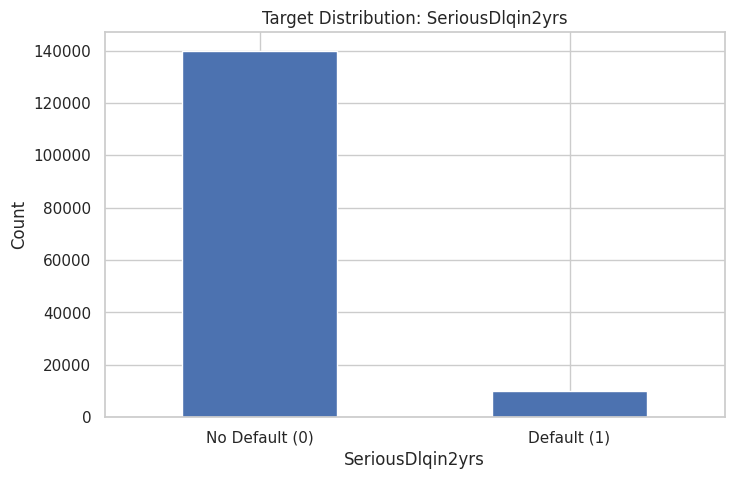

In [ ]:
target_col = "SeriousDlqin2yrs"

fig, ax = plt.subplots()
df[target_col].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(["No Default (0)", "Default (1)"], rotation=0)
ax.set_title("Target Distribution: SeriousDlqin2yrs")
ax.set_ylabel("Count")
plt.show()

# **Missing Values Overview**

MonthlyIncome                           0.198207
NumberOfDependents                      0.026160
SeriousDlqin2yrs                        0.000000
age                                     0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
DebtRatio                               0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
dtype: float64


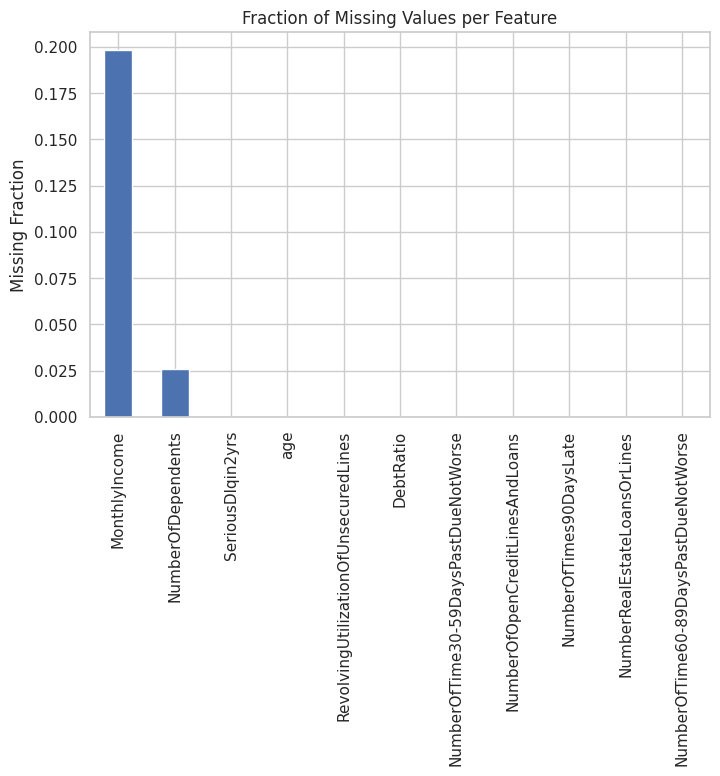

In [ ]:
missing_ratio = df.isna().mean().sort_values(ascending=False)

print(missing_ratio)

plt.figure()
missing_ratio.plot(kind="bar")
plt.title("Fraction of Missing Values per Feature")
plt.ylabel("Missing Fraction")
plt.show()

# **Numeric Feature Distributions**

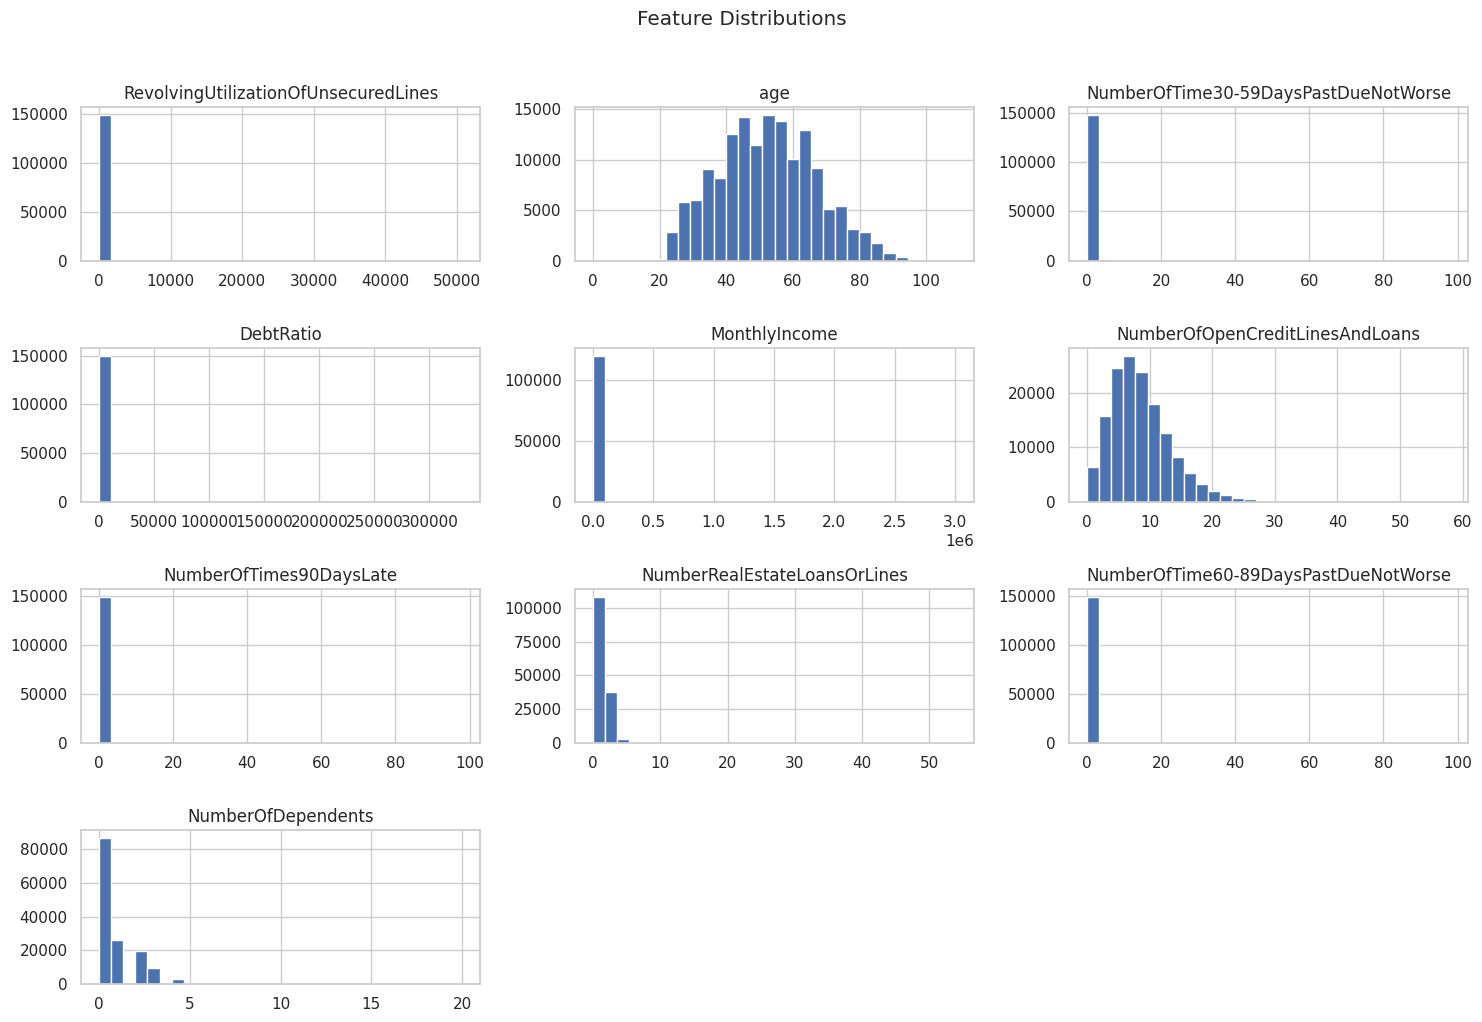

In [ ]:
numeric_cols = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# **Correlation Heatmap**

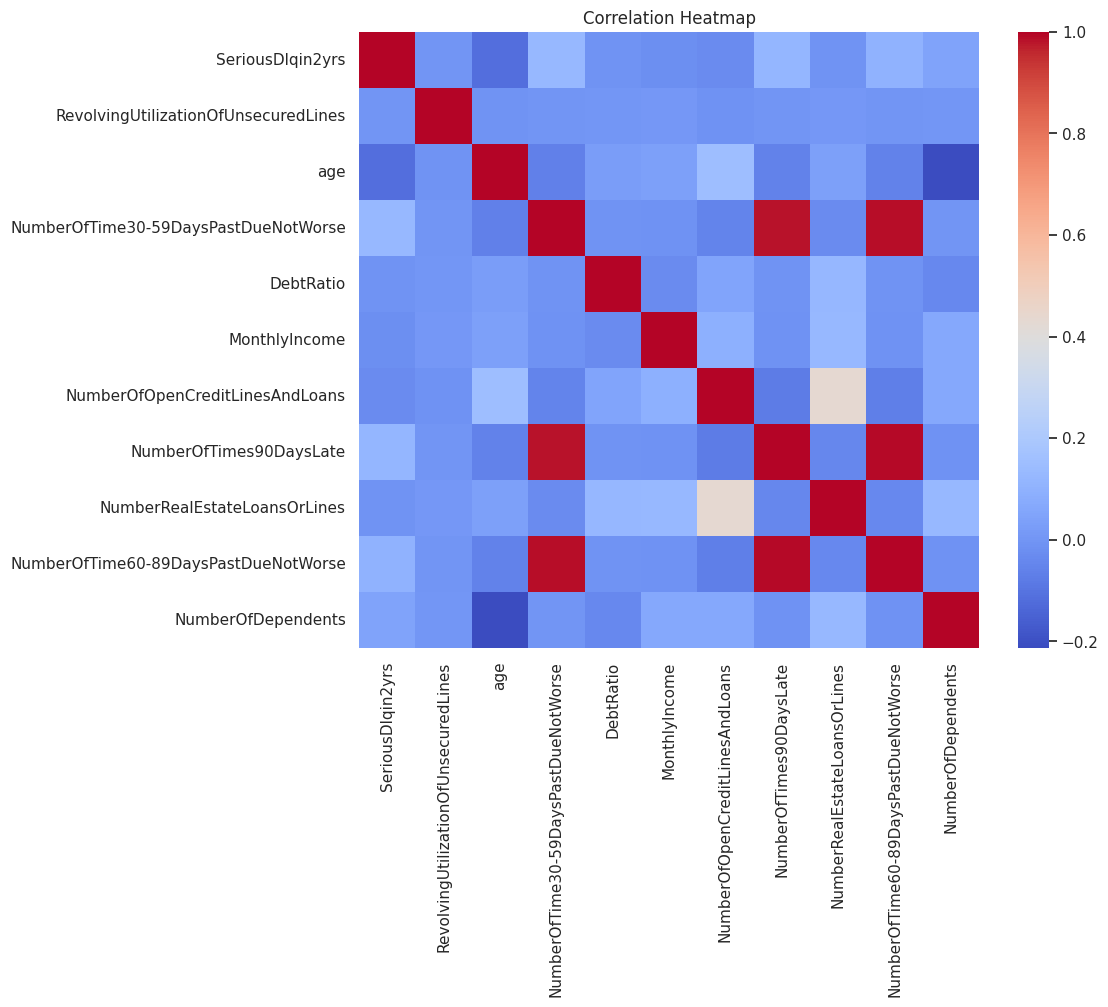

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# **Define Features & Target**

In [ ]:
y = df[target_col]
X = df.drop(columns=[target_col])

print("X shape:", X.shape)
print("y shape:", y.shape)

# Quick look at missing values in features
X.isna().mean().sort_values(ascending=False)

X shape: (150000, 10)
y shape: (150000,)


,0
MonthlyIncome,0.198207
NumberOfDependents,0.026160
age,0.000000
RevolvingUtilizationOfUnsecuredLines,0.000000
DebtRatio,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0.000000
NumberOfOpenCreditLinesAndLoans,0.000000
NumberOfTimes90DaysLate,0.000000
NumberRealEstateLoansOrLines,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0.000000


# **Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (120000, 10) (120000,)
Test shape: (30000, 10) (30000,)


# **Build Pipelines (LogReg, RF, GB, XGBoost)**

In [ ]:
numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

# Imbalance adjustment for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

# Define models
log_reg_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

gb_clf = GradientBoostingClassifier(
    random_state=42
)

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Pipelines
pipe_log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", log_reg_clf)
])

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf_clf)
])

pipe_gb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", gb_clf)
])

pipe_xgb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_clf)
])

models = {
    "Logistic Regression": pipe_log_reg,
    "Random Forest": pipe_rf,
    "Gradient Boosting": pipe_gb,
    "XGBoost": pipe_xgb
}

# **Helper Function for Evaluation**

In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n=== {name} ===")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print("AUC-ROC  :", auc)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC_ROC": auc
    }

# **Train All Models & Compare**

In [ ]:
results = []
fitted_models = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    fitted_models[name] = model
    metrics = evaluate_model(name, model, X_test, y_test)
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("Model")
results_df


--- Training Logistic Regression ---

=== Logistic Regression ===
Accuracy : 0.7762333333333333
Precision: 0.18163375710035162
Recall   : 0.6698254364089775
F1-score : 0.28577508245558036
AUC-ROC  : 0.8021461794700605

Classification Report:
              precision    recall  f1-score   support

           0     0.9707    0.7839    0.8673     27995
           1     0.1816    0.6698    0.2858      2005

    accuracy                         0.7762     30000
   macro avg     0.5762    0.7268    0.5766     30000
weighted avg     0.9180    0.7762    0.8285     30000


--- Training Random Forest ---

=== Random Forest ===
Accuracy : 0.9354
Precision: 0.5614678899082569
Recall   : 0.15261845386533665
F1-score : 0.24
AUC-ROC  : 0.8401676287937061

Classification Report:
              precision    recall  f1-score   support

           0     0.9423    0.9915    0.9663     27995
           1     0.5615    0.1526    0.2400      2005

    accuracy                         0.9354     30000
   macro

,Accuracy,Precision,Recall,F1,AUC_ROC
Model,,,,,
Logistic Regression,0.776233,0.181634,0.669825,0.285775,0.802146
Random Forest,0.935400,0.561468,0.152618,0.240000,0.840168
Gradient Boosting,0.937600,0.598519,0.201496,0.301493,0.867594
XGBoost,0.805100,0.222238,0.766584,0.344580,0.866093


# **ROC Curves**

<Figure size 800x600 with 0 Axes>

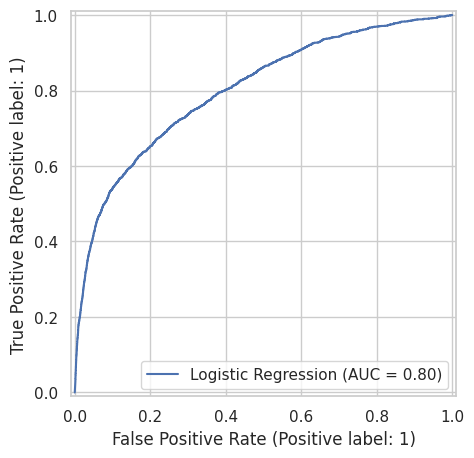

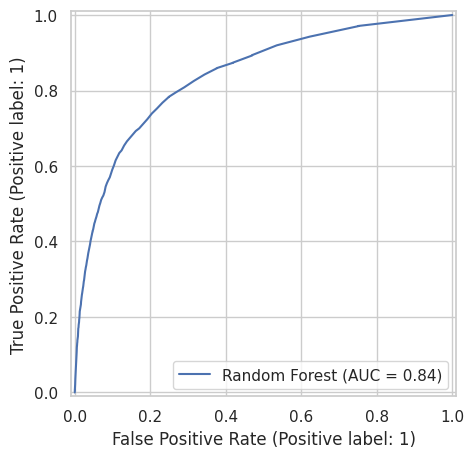

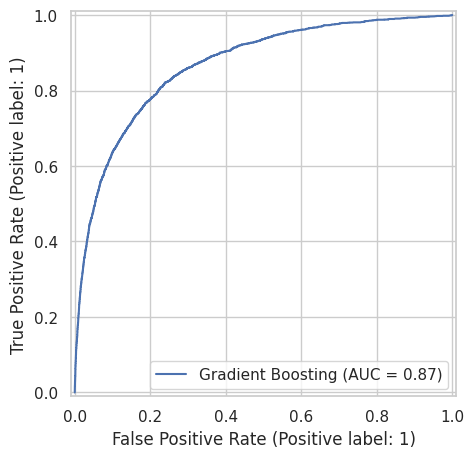

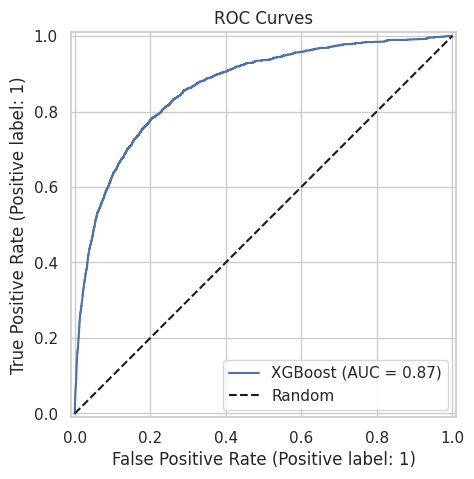

In [ ]:
plt.figure(figsize=(8, 6))

for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        name=name
    )

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("ROC Curves")
plt.legend()
plt.show()

# **Select Best Model & Save It**

In [ ]:
best_row = results_df.sort_values("AUC_ROC", ascending=False).iloc[0]
best_model_name = best_row.name
best_model = fitted_models[best_model_name]

print("Best model based on AUC-ROC:", best_model_name)
print(best_row)

MODEL_FILENAME = "best_credit_model.pkl"
FEATURES_FILENAME = "feature_names.pkl"

joblib.dump(best_model, MODEL_FILENAME)
joblib.dump(numeric_features, FEATURES_FILENAME)

print(f"\nSaved best model to {MODEL_FILENAME}")
print(f"Saved feature list to {FEATURES_FILENAME}")

Best model based on AUC-ROC: Gradient Boosting
Accuracy     0.937600
Precision    0.598519
Recall       0.201496
F1           0.301493
AUC_ROC      0.867594
Name: Gradient Boosting, dtype: float64

Saved best model to best_credit_model.pkl
Saved feature list to feature_names.pkl


# **Fairness / Bias Analysis (Age Groups)**

In [ ]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

age_test = X_test["age"]
sensitive_feature = np.where(age_test < 30, "Under_30", "ThirtyPlus")

metrics_dict = {
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate
}

mf = MetricFrame(
    metrics=metrics_dict,
    y_true=y_test,
    y_pred=y_pred_best,
    sensitive_features=sensitive_feature
)

print("Overall metrics:")
print(mf.overall)

print("\nMetrics by age group:")
print(mf.by_group)

Overall metrics:
selection_rate         0.022500
false_positive_rate    0.009680
true_positive_rate     0.201496
dtype: float64

Metrics by age group:
                     selection_rate  false_positive_rate  true_positive_rate
sensitive_feature_0                                                         
ThirtyPlus                 0.020593             0.008722            0.197413
Under_30                   0.053510             0.026473            0.233480


# **Bar Plots for Fairness Metrics**

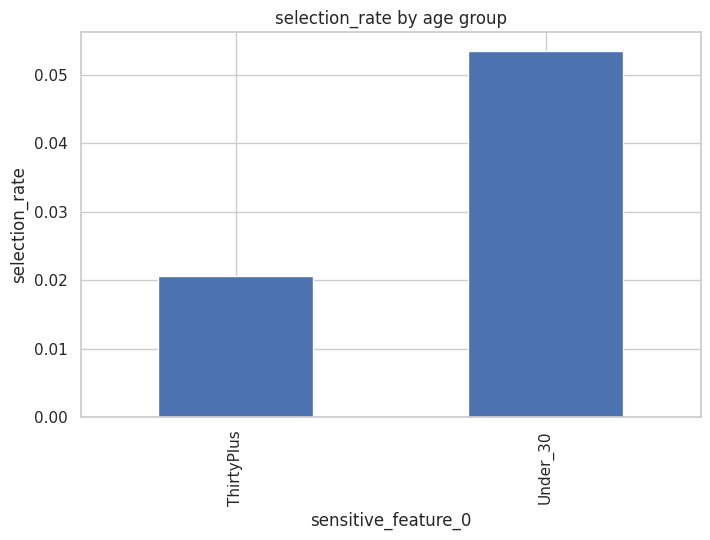

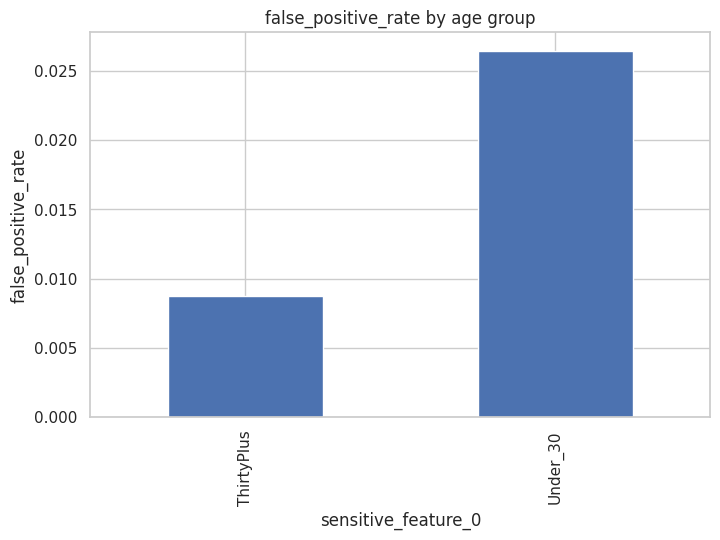

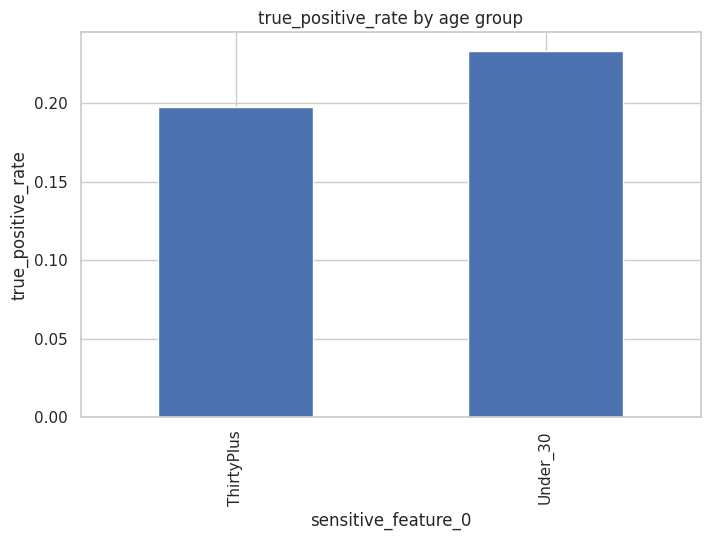

In [ ]:
for metric_name in metrics_dict.keys():
    plt.figure()
    mf.by_group[metric_name].plot(kind='bar')
    plt.title(f"{metric_name} by age group")
    plt.ylabel(metric_name)
    plt.show()

# **Use Best Model on cs-test.csv (Optional Submission File)**

In [ ]:
df_test = pd.read_csv(TEST_PATH)

# Drop index column if present
id_col = None
if 'Unnamed: 0' in df_test.columns:
    id_col = 'Unnamed: 0'
    ids = df_test[id_col]
    df_test = df_test.drop(columns=[id_col])
elif 'Id' in df_test.columns:
    id_col = 'Id'
    ids = df_test[id_col]
else:
    ids = df_test.index  # fallback

X_test_kaggle = df_test[numeric_features]

test_proba = best_model.predict_proba(X_test_kaggle)[:, 1]

submission = pd.DataFrame({
    "Id": ids,
    "Probability": test_proba
})

submission.to_csv("submission.csv", index=False)
submission.head()

,Id,Probability
0,1,0.072174
1,2,0.051096
2,3,0.013199
3,4,0.067060
4,5,0.092142
